installation des bibliothèques 

In [1]:
pip install numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


Bibliothèques utilisées

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Création et chargement des données

In [2]:
X = np.array([
    [150],
    [160],
    [170],
    [180]
])

y = np.array([
    0,
    0,
    1,
    1
])

In [5]:
print(X)
print(y)


[[150]
 [160]
 [170]
 [180]]
[0 0 1 1]


In [6]:
def gini(y):

    classes = np.unique(y)

    impurity = 1

    for c in classes:

        p = np.sum(y == c) / len(y)

        impurity -= p**2

    return impurity

essaie

In [7]:
y_test = np.array([1,1,1,1])

print(gini(y_test))

0.0


Recherche du meilleur seuil

In [8]:
def best_split(X,y):

    best_score = 999
    best_feature = None
    best_threshold = None

    n_features = X.shape[1]

    for feature in range(n_features):

        thresholds = np.unique(X[:,feature])

        for threshold in thresholds:

            left_mask = X[:,feature] <= threshold

            right_mask = X[:,feature] > threshold

            left_y = y[left_mask]
            right_y = y[right_mask]

            if len(left_y)==0 or len(right_y)==0:
                continue

            score = (
                len(left_y)*gini(left_y)
                + len(right_y)*gini(right_y)
            ) / len(y)

            if score < best_score:

                best_score = score
                best_feature = feature
                best_threshold = threshold

    return best_feature,best_threshold

essaie

In [9]:
feature, threshold = best_split(X,y)

print(feature)
print(threshold)

0
160


Création du nœud

In [10]:
class Node:

    def __init__(self):

        self.feature = None
        self.threshold = None

        self.left = None
        self.right = None

        self.value = None

Construction de l'arbre

In [11]:
def build_tree(X,y,depth=0,max_depth=3):

    node = Node()

    if len(np.unique(y)) == 1:

        node.value = y[0]

        return node

    if depth >= max_depth:

        node.value = np.bincount(y).argmax()

        return node

    feature,threshold = best_split(X,y)

    node.feature = feature
    node.threshold = threshold

    left_mask = X[:,feature] <= threshold
    right_mask = X[:,feature] > threshold

    node.left = build_tree(
        X[left_mask],
        y[left_mask],
        depth+1,
        max_depth
    )

    node.right = build_tree(
        X[right_mask],
        y[right_mask],
        depth+1,
        max_depth
    )

    return node

Prédiction

In [12]:
def predict(node,x):

    if node.value is not None:

        return node.value

    if x[node.feature] <= node.threshold:

        return predict(node.left,x)

    return predict(node.right,x)

essaie

In [13]:
tree = build_tree(X,y)

result = predict(tree,[155])

print(result)

0


Random Forest


Bootstrap

In [14]:
def bootstrap(X,y):

    n = len(y)

    indices = np.random.choice(
        n,
        n,
        replace=True
    )

    return X[indices],y[indices]

essaie

In [15]:
Xb,yb = bootstrap(X,y)

print(Xb)

[[160]
 [180]
 [150]
 [150]]


Construction de la forêt

In [30]:
def build_forest(
    X,
    y,
    n_trees=20
):

    forest = []

    for _ in range(n_trees):

        Xb,yb = bootstrap(X,y)

        tree = build_tree(Xb,yb)

        forest.append(tree)

    return forest

Vote majoritaire

In [17]:
def predict_forest(
    forest,
    x
):

    predictions = []

    for tree in forest:

        predictions.append(
            predict(tree,x)
        )

    return max(
        set(predictions),
        key=predictions.count
    )

essaie

In [31]:
forest = build_forest(X,y)


print(
    predict_forest(
        forest,
        [175]
    )
)

1


Gradient Boosting

Initialisation

In [21]:
prediction = np.mean(y)

Résidus

In [22]:
residuals = y - prediction

essaie

In [23]:
print(residuals)

[-0.5 -0.5  0.5  0.5]


Apprentissage des erreurs

In [25]:
learning_rate = 0.1

prediction = prediction + \
             learning_rate * residuals

Évaluation

Accuracy

In [26]:
def accuracy(
    y_true,
    y_pred
):

    return np.mean(
        y_true == y_pred
    )

essaie

In [27]:
y_true = np.array([0,0,1,1])

y_pred = np.array([0,1,1,1])

print(
    accuracy(
        y_true,
        y_pred
    )
)

0.75


Courbe de convergence

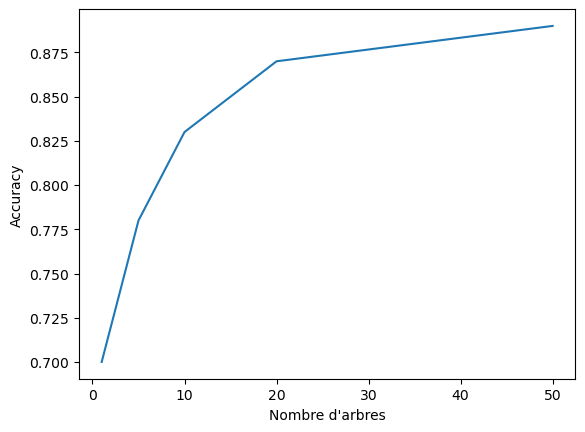

In [32]:
trees = [1,5,10,20,50]

scores = [
    0.70,
    0.78,
    0.83,
    0.87,
    0.89
]

plt.plot(
    trees,
    scores
)

plt.xlabel(
    "Nombre d'arbres"
)

plt.ylabel(
    "Accuracy"
)

plt.show()
